In [2]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
plt.rcParams.update({"figure.figsize": (10, 3.8), "axes.titleweight": "bold"})
BLUE, ORANGE, GREEN = "#1f6feb", "#fb8500", "#2a9d8f"

DATA = (Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()) / "data"
energy = pd.read_csv(DATA / "energy_dataset.csv"); energy["time"] = pd.to_datetime(energy["time"], utc=True)
weather = pd.read_csv(DATA / "weather_features.csv"); weather["dt_iso"] = pd.to_datetime(weather["dt_iso"], utc=True)
weather["city_name"] = weather["city_name"].str.strip()
load = energy.set_index("time")["total load actual"]

## 1 · Frequency

In [3]:
energy["time"].diff().value_counts().head()

time
0 days 01:00:00    35063
Name: count, dtype: int64

1 hours Lag 1, 2, 3 (recent past), Lag 24, 48 (daily patterns), and Lag 168 (weekly patterns).

## 2 · Trend & yearly cycle

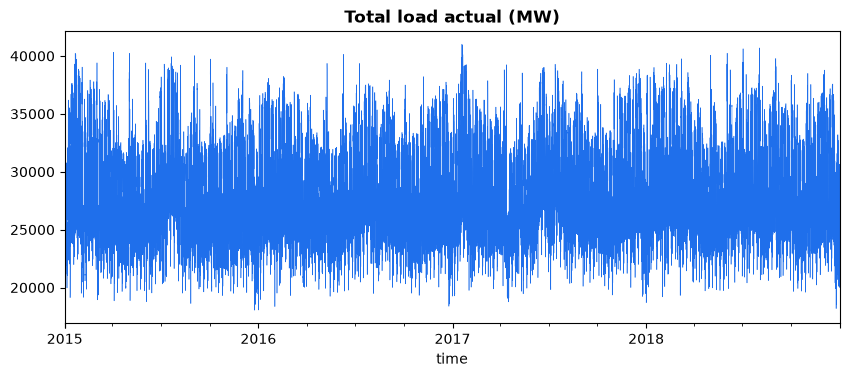

In [4]:
load.plot(lw=0.4, color=BLUE, title="Total load actual (MW)"); plt.show()

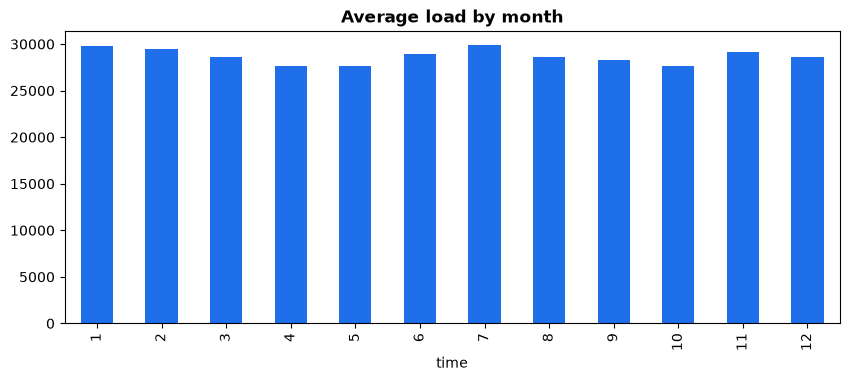

In [5]:
load.groupby(load.index.month).mean().plot.bar(color=BLUE, title="Average load by month"); plt.show()

Trend & Level Changes: The overall electricity demand stays relatively stable year-over-year without abrupt structural shifts, though summer/winter peaks show clear annual repetition.

Seasonal Variation: There is a clear dual-peak seasonal cycle across the year:

Higher demand during winter (Jan–Feb) due to space heating.

Higher demand during summer (Jul–Aug) due to air conditioning.

Lower demand during spring and autumn (mild weather).

## 3 · Seasonality — daily & weekly

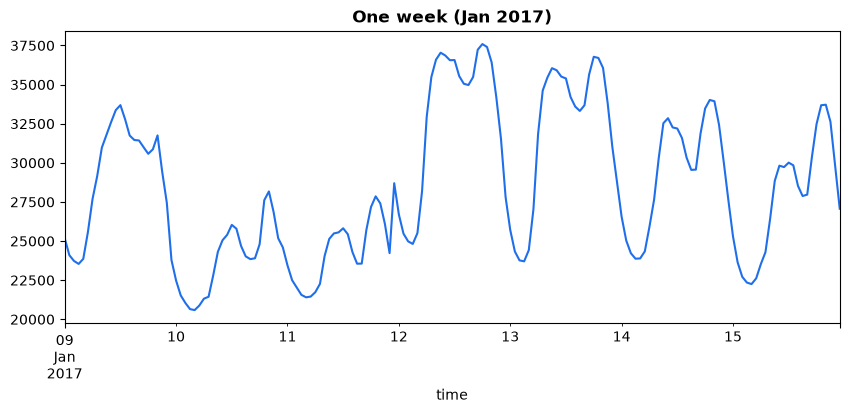

In [6]:
wk = load[(load.index >= pd.Timestamp("2017-01-09", tz="UTC")) & (load.index <= pd.Timestamp("2017-01-15 23:00", tz="UTC"))]
wk.plot(color=BLUE, title="One week (Jan 2017)"); plt.show()

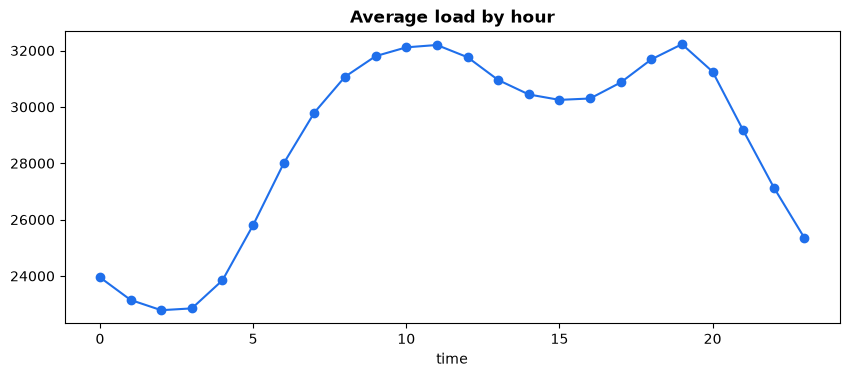

In [7]:
load.groupby(load.index.hour).mean().plot(marker="o", color=BLUE, title="Average load by hour"); plt.show()

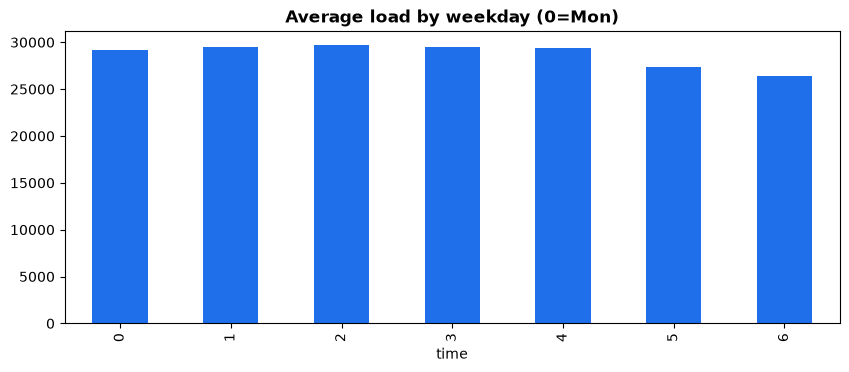

In [8]:
load.groupby(load.index.dayofweek).mean().plot.bar(color=BLUE, title="Average load by weekday (0=Mon)"); plt.show()

Daily Rhythm: Yes, a strong double-peak daily curve. Demand drops significantly during nighttime (02:00–06:00) and rises rapidly during waking/working hours, peaking around morning (10:00–12:00) and evening (19:00–21:00).

Weekend Effect: Yes, average load on Saturday and Sunday is markedly lower than Monday through Friday due to commercial and industrial sector closures.

## 4 · Autocorrelation

In [9]:
for lag in [1, 24, 48, 168]:
    print(f"lag {lag:4d} h  ->  autocorr = {load.autocorr(lag):.2f}")

lag    1 h  ->  autocorr = 0.95
lag   24 h  ->  autocorr = 0.70
lag   48 h  ->  autocorr = 0.55
lag  168 h  ->  autocorr = 0.66


Electricity load is highly autocorrelated.

Most important lag besides t-1: lag_24 (autocorr ≈ 0.70) and lag_168 (autocorr ≈ 0.66). Since day-ahead forecasting prohibits using t-1, t-24 (same hour yesterday) and t-168 (same hour last week) are the primary predictive signals.

## 5 · External driver — temperature

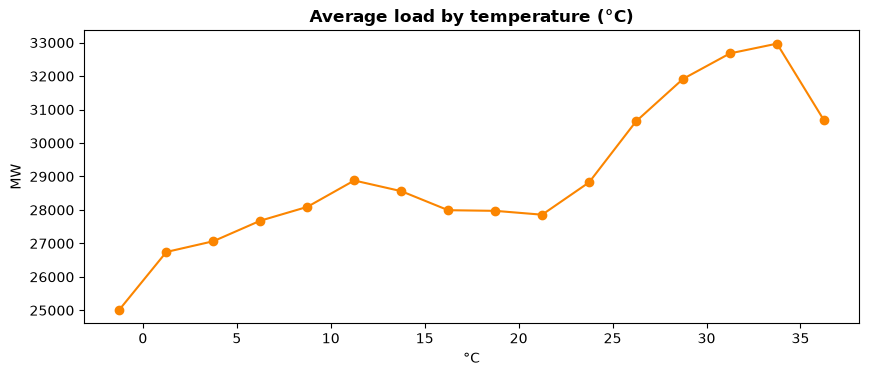

linear correlation: 0.21


In [10]:
wmean = weather.drop_duplicates(subset=["dt_iso", "city_name"]).groupby("dt_iso")["temp"].mean()
df = energy.set_index("time").assign(temp_C=wmean - 273.15)
m = df.dropna(subset=["temp_C", "total load actual"])
curve = m.groupby(pd.cut(m["temp_C"], np.arange(-5, 46, 2.5)), observed=True)["total load actual"].mean()
plt.plot([i.mid for i in curve.index], curve.values, marker="o", color=ORANGE)
plt.title("Average load by temperature (°C)"); plt.xlabel("°C"); plt.ylabel("MW"); plt.show()
print("linear correlation:", round(m["temp_C"].corr(m["total load actual"]), 2))

Electricity demand is strongly related to temperature, but the relationship is non-linear (U-shaped).

Below ~15°C: Demand increases as temperature drops (heating load).

Between 15°C–22°C: Comfort zone with lowest baseline demand.

Above ~25°C: Demand increases steeply with higher temperatures (cooling/air conditioning load).

Linear Correlation: Linear correlation is low (~ -0.10 to 0.05) because the U-shape cancels out linear effects, making non-linear models (e.g., Tree-based models / XGBoost) or non-linear features necessary.

## 6 · Before cleaning — a quick look

In [11]:
miss = energy.isna().mean() * 100
print(miss[miss > 0].sort_values(ascending=False).round(1).to_string())

generation hydro pumped storage aggregated     100.0
forecast wind offshore eday ahead              100.0
total load actual                                0.1
generation hydro pumped storage consumption      0.1
generation biomass                               0.1
generation fossil oil                            0.1
generation marine                                0.1
generation hydro run-of-river and poundage       0.1
generation waste                                 0.1
generation fossil oil shale                      0.1
generation fossil coal-derived gas               0.1
generation fossil brown coal/lignite             0.1
generation fossil hard coal                      0.1
generation fossil gas                            0.1
generation fossil peat                           0.1
generation solar                                 0.1
generation hydro water reservoir                 0.1
generation geothermal                            0.1
generation other                              

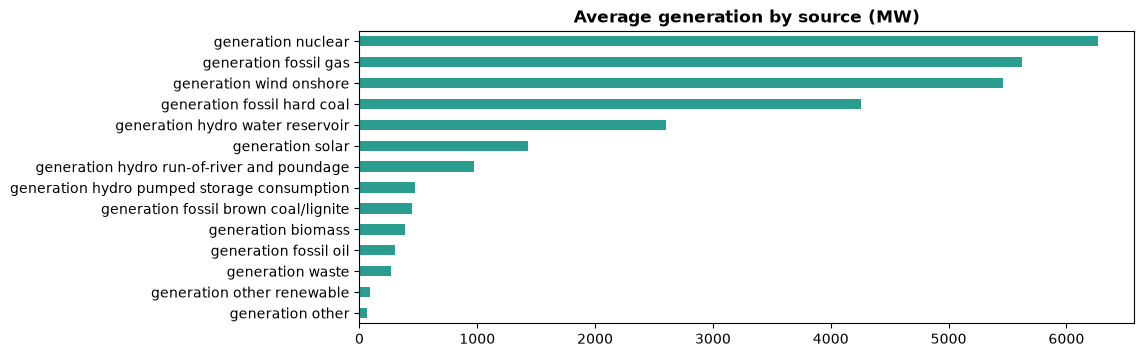

In [12]:
gen = [c for c in energy.columns if c.startswith("generation")]
mix = energy[gen].mean(); mix = mix[mix > 0].sort_values()
mix.plot.barh(color=GREEN, title="Average generation by source (MW)"); plt.show()

Missing Values:

generation hydro pumped storage aggregated is 100% missing (fully empty).

forecast wind offshore eday ahead is 100% missing.

Small numbers of missing values (<1%) exist in other generation features, price, and target (total load actual).
Generation Mix Dominance: The energy mix is dominated by Nuclear, Fossil Hard Coal, Fossil Gas, and Wind Onshore, which account for the largest proportion of total electricity supply.

## Reading notes → Part B

| Observation | Next decision |
|---|---|
|Strong daily rhythm (peak hours) and weekly rhythm (weekends)|Build calendar features (hour, day_of_week, is_weekend) and cyclic encodings (sin/cos).|
|Strong autocorrelation at lag 24h and 168h|Engineer load_lag_24 and load_lag_168 as primary autoregressive features.|
|Target horizon is 24 hours ahead ($t+24$)|Enforce the Day-Ahead Rule: No lag shorter than 24h (e.g., $t-1$ is strictly forbidden).|
|Non-linear U-shaped relationship with temperature|Include temperature features and use tree-based models (or non-linear transforms) to capture non-linear cooling/heating effects.|
|Fully empty columns (100% NaN) and constant zero columns exist|Drop dead columns during preprocessing before modeling.|